# Bit Allocation By Metric With Structural Layer IDs

读取 `single_flip_top_bits_topk_1000.json`，按不同 metric 可视化 bit allocation。

- 按模型拆分：vision 单独绘制，policy 单独绘制
- 横轴：各自模型内部的结构层编号
- `layer_id` 来自 ONNX initializer 的结构顺序，不再是原始 tensor name 出现顺序
- metadata pkl 只用于补充模型元信息，结构层顺序本身来自 ONNX

In [1]:
import csv
import json
import pickle
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import onnx

plt.style.use("default")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "figure.edgecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#303030",
        "axes.labelcolor": "#202020",
        "axes.titlecolor": "#202020",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "text.color": "#202020",
        "xtick.color": "#202020",
        "ytick.color": "#202020",
        "grid.color": "#D9D9D9",
        "grid.alpha": 0.35,
    }
)

BASE_DIR = Path("/home/xzha135/work/projects_ws/DAC/STAFI/op_0103")
MODEL_DIR = BASE_DIR / "models"
DATA_PATH = BASE_DIR / "out/single_flip_top_bits_topk_1000.json"
WEIGHTS_PATH = BASE_DIR / "saved_out/weights_candidates_0103_with_bias_20260305-143550.json"
OUTPUT_DIR = BASE_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ARTIFACTS = {
    "vision": {
        "onnx": MODEL_DIR / "driving_vision.onnx",
        "metadata": MODEL_DIR / "driving_vision_metadata.pkl",
    },
    "policy": {
        "onnx": MODEL_DIR / "driving_policy.onnx",
        "metadata": MODEL_DIR / "driving_policy_metadata.pkl",
    },
}

In [2]:
with DATA_PATH.open("r", encoding="utf-8") as f:
    payload = json.load(f)

with WEIGHTS_PATH.open("r", encoding="utf-8") as f:
    weights_payload = json.load(f)

payload.keys(), weights_payload.keys()

(dict_keys(['meta', 'baseline_metrics', 'top_by_metric']),
 dict_keys(['meta', 'candidates']))

In [3]:
def normalize_model_group(model_name, tensor_name=""):
    model_text = str(model_name).lower()
    if model_text in {"vision", "policy"}:
        return model_text

    text = f"{model_name} {tensor_name}".lower()
    if "vision" in text:
        return "vision"
    if "policy" in text:
        return "policy"
    return "other"


def canonicalize_tensor_name(name, selected_group):
    canonical = str(name)
    if canonical.startswith("vision_model."):
        canonical = canonical[len("vision_model.") :]
    if canonical.startswith("policy_model."):
        canonical = canonical[len("policy_model.") :]

    if selected_group == "vision" and canonical.startswith(("summarizer.", "hydra.", "resblock.", "res_layer.", "in_layer.")):
        canonical = f"policy.{canonical}"

    return canonical


def structural_layer_key(name, selected_group):
    canonical = canonicalize_tensor_name(name, selected_group)
    if canonical == "pad":
        return None

    for suffix in (".weight", ".bias", ".gamma", ".beta"):
        if canonical.endswith(suffix):
            canonical = canonical[: -len(suffix)]
            break

    canonical = canonical.replace(".reparam_conv", "")
    canonical = canonical.replace(".conv.conv", ".conv")
    return canonical


def load_model_structure_info(model_artifacts):
    structure_order_by_group = {}
    model_metadata_by_group = {}

    for model_group, artifact_paths in model_artifacts.items():
        with artifact_paths["metadata"].open("rb") as f:
            model_metadata_by_group[model_group] = pickle.load(f)

        onnx_model = onnx.load(str(artifact_paths["onnx"]))
        ordered_keys = []
        seen = set()
        for initializer in onnx_model.graph.initializer:
            layer_key = structural_layer_key(initializer.name, model_group)
            if layer_key is None or layer_key in seen:
                continue
            ordered_keys.append(layer_key)
            seen.add(layer_key)
        structure_order_by_group[model_group] = ordered_keys

    return structure_order_by_group, model_metadata_by_group


def build_structural_layer_maps(payload, weights_data, structure_order_by_group):
    relevant_keys_by_group = {model_group: set() for model_group in structure_order_by_group}
    top_by_metric = payload.get("top_by_metric", {})

    for row in weights_data.get("candidates", []):
        model_group = normalize_model_group(row.get("model", ""), row.get("name", ""))
        if model_group not in relevant_keys_by_group:
            continue
        layer_key = structural_layer_key(row.get("name", ""), model_group)
        if layer_key is not None:
            relevant_keys_by_group[model_group].add(layer_key)

    for metric_rows in top_by_metric.values():
        for row in metric_rows:
            model_group = normalize_model_group(row.get("model", ""), row.get("name", ""))
            if model_group not in relevant_keys_by_group:
                continue
            layer_key = structural_layer_key(row.get("name", ""), model_group)
            if layer_key is not None:
                relevant_keys_by_group[model_group].add(layer_key)

    layer_maps_by_group = {}
    for model_group, ordered_keys in structure_order_by_group.items():
        selected_keys = [key for key in ordered_keys if key in relevant_keys_by_group[model_group]]
        missing_keys = sorted(relevant_keys_by_group[model_group] - set(selected_keys))
        final_keys = selected_keys + missing_keys
        layer_maps_by_group[model_group] = {key: idx + 1 for idx, key in enumerate(final_keys)}

    return layer_maps_by_group


def build_bit_allocation_records(payload, layer_maps_by_group):
    top_by_metric = payload.get("top_by_metric", {})
    records = []

    for metric, rows in top_by_metric.items():
        group_rank = defaultdict(int)
        for rank, row in enumerate(rows, start=1):
            model_group = normalize_model_group(row.get("model", ""), row.get("name", ""))
            if model_group not in layer_maps_by_group:
                continue

            layer_key = structural_layer_key(row["name"], model_group)
            if layer_key is None:
                continue
            if layer_key not in layer_maps_by_group[model_group]:
                layer_maps_by_group[model_group][layer_key] = len(layer_maps_by_group[model_group]) + 1

            group_rank[model_group] += 1
            records.append(
                {
                    "metric": metric,
                    "rank": rank,
                    "group_rank": group_rank[model_group],
                    "model": row.get("model", "unknown"),
                    "model_group": model_group,
                    "name": row["name"],
                    "layer_key": layer_key,
                    "layer_id": layer_maps_by_group[model_group][layer_key],
                    "bit": int(row["bit"]),
                    "flat": int(row["flat"]),
                    "weight_score": float(row.get("weight_score", np.nan)),
                    "metric_delta": float(row.get("delta", {}).get(metric, np.nan)),
                    "metric_value": float(row.get("flipped_metrics", {}).get(metric, np.nan)),
                }
            )

    records.sort(key=lambda item: (item["model_group"], item["metric"], item["layer_id"], item["bit"], item["rank"]))
    return records


def summarize_records(records):
    summary = []
    grouped = defaultdict(list)
    for row in records:
        grouped[(row["model_group"], row["metric"])].append(row)

    for (model_group, metric), items in grouped.items():
        bits = [item["bit"] for item in items]
        layers = {item["layer_id"] for item in items}
        summary.append(
            {
                "model_group": model_group,
                "metric": metric,
                "num_points": len(items),
                "unique_layers": len(layers),
                "min_bit": min(bits),
                "max_bit": max(bits),
            }
        )
    summary.sort(key=lambda item: (item["model_group"], item["metric"]))
    return summary


def print_table(rows, columns, max_rows=None):
    show_rows = rows if max_rows is None else rows[:max_rows]
    widths = {col: len(col) for col in columns}
    for row in show_rows:
        for col in columns:
            widths[col] = max(widths[col], len(str(row.get(col, ""))))

    header = " | ".join(str(col).ljust(widths[col]) for col in columns)
    sep = "-+-".join("-" * widths[col] for col in columns)
    print(header)
    print(sep)
    for row in show_rows:
        print(" | ".join(str(row.get(col, "")).ljust(widths[col]) for col in columns))


structure_order_by_group, model_metadata_by_group = load_model_structure_info(MODEL_ARTIFACTS)
layer_maps_by_group = build_structural_layer_maps(payload, weights_payload, structure_order_by_group)
df_bits = build_bit_allocation_records(payload, layer_maps_by_group)
summary_rows = summarize_records(df_bits)
records_by_group = {
    model_group: [row for row in df_bits if row["model_group"] == model_group]
    for model_group in ["vision", "policy"]
}

print("Total plotted points:", len(df_bits))
for model_group, rows in records_by_group.items():
    print(f"{model_group} points: {len(rows)}")
    print(f"{model_group} structural layers used in data: {len({row['layer_id'] for row in rows})}")
    print(f"{model_group} model inputs: {list(model_metadata_by_group[model_group].get('input_shapes', {}).keys())}")

print_table(summary_rows, ["model_group", "metric", "num_points", "unique_layers", "min_bit", "max_bit"])

Total plotted points: 5000
vision points: 3831
vision structural layers used in data: 16
vision model inputs: ['img', 'big_img']
policy points: 1169
policy structural layers used in data: 1
policy model inputs: ['desire_pulse', 'traffic_convention', 'features_buffer']
model_group | metric   | num_points | unique_layers | min_bit | max_bit
------------+----------+------------+---------------+---------+--------
policy      | +diffx   | 356        | 1             | 13      | 14     
policy      | +diffy   | 203        | 1             | 13      | 14     
policy      | -diffx   | 81         | 1             | 9       | 15     
policy      | -diffy   | 245        | 1             | 8       | 15     
policy      | loss_mse | 284        | 1             | 10      | 15     
vision      | +diffx   | 644        | 15            | 9       | 15     
vision      | +diffy   | 797        | 15            | 9       | 15     
vision      | -diffx   | 919        | 16            | 8       | 15     
vision     


Drawing plots for vision: ['loss_mse', '+diffx', '-diffx', '+diffy', '-diffy']


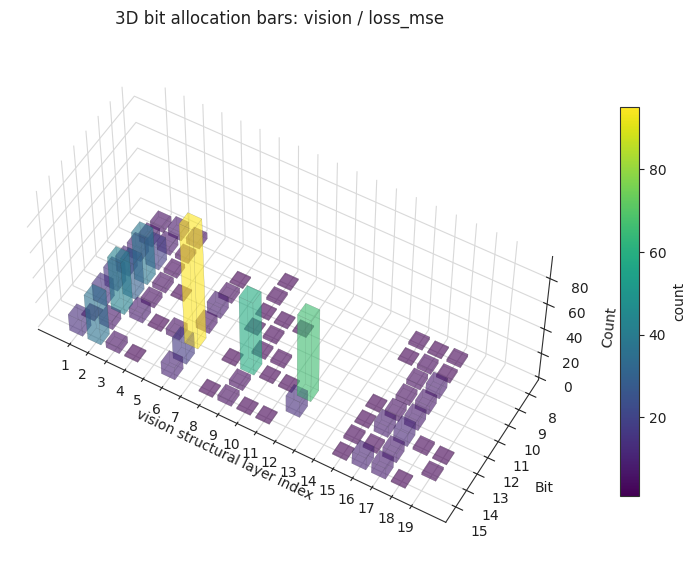

Saved 3D bar plot to: /home/xzha135/work/projects_ws/DAC/STAFI/op_0103/figures/bit_allocation_3dbar_vision_loss_mse_structural.png


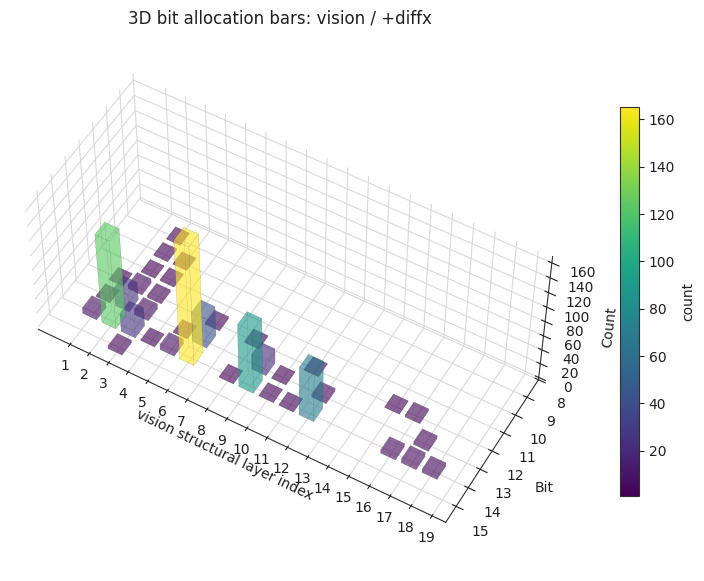

Saved 3D bar plot to: /home/xzha135/work/projects_ws/DAC/STAFI/op_0103/figures/bit_allocation_3dbar_vision_posdiffx_structural.png


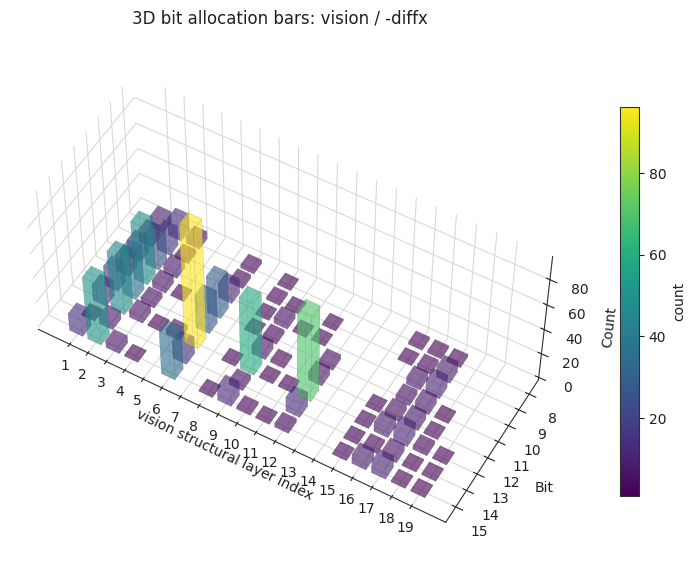

Saved 3D bar plot to: /home/xzha135/work/projects_ws/DAC/STAFI/op_0103/figures/bit_allocation_3dbar_vision_negdiffx_structural.png


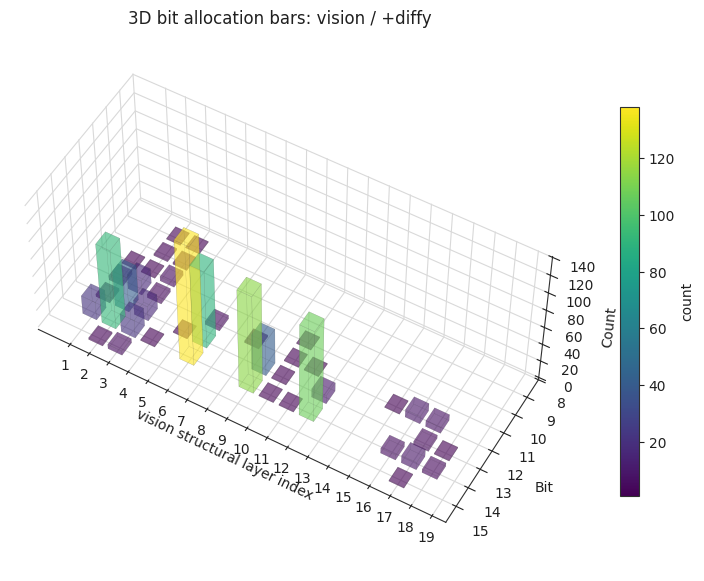

Saved 3D bar plot to: /home/xzha135/work/projects_ws/DAC/STAFI/op_0103/figures/bit_allocation_3dbar_vision_posdiffy_structural.png


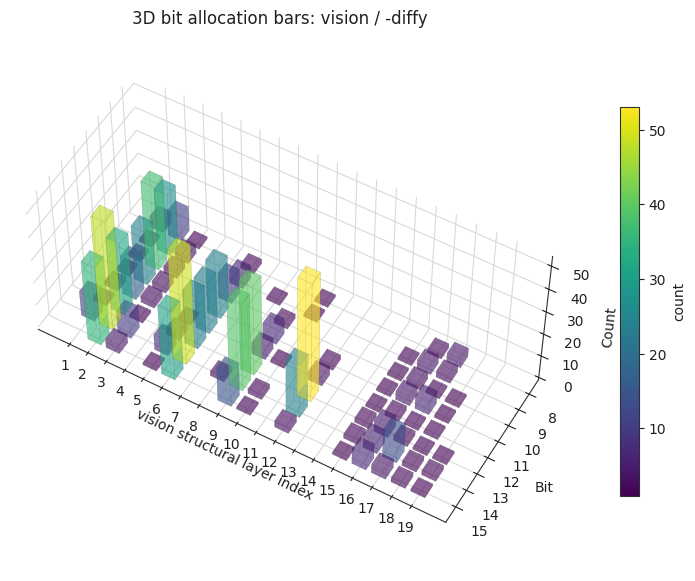

Saved 3D bar plot to: /home/xzha135/work/projects_ws/DAC/STAFI/op_0103/figures/bit_allocation_3dbar_vision_negdiffy_structural.png

Drawing plots for policy: ['loss_mse', '+diffx', '-diffx', '+diffy', '-diffy']


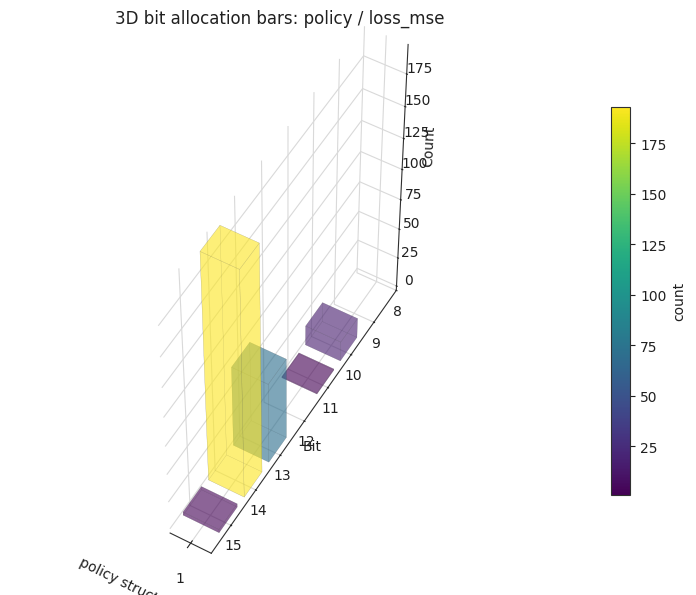

Saved 3D bar plot to: /home/xzha135/work/projects_ws/DAC/STAFI/op_0103/figures/bit_allocation_3dbar_policy_loss_mse_structural.png


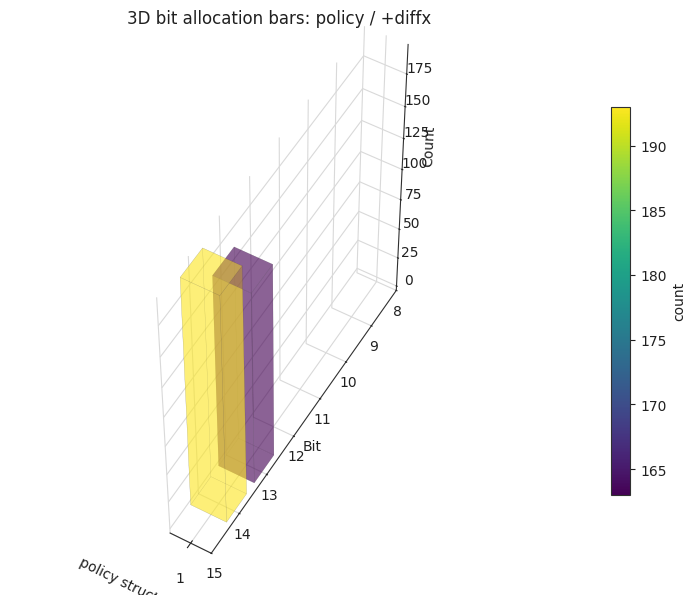

Saved 3D bar plot to: /home/xzha135/work/projects_ws/DAC/STAFI/op_0103/figures/bit_allocation_3dbar_policy_posdiffx_structural.png


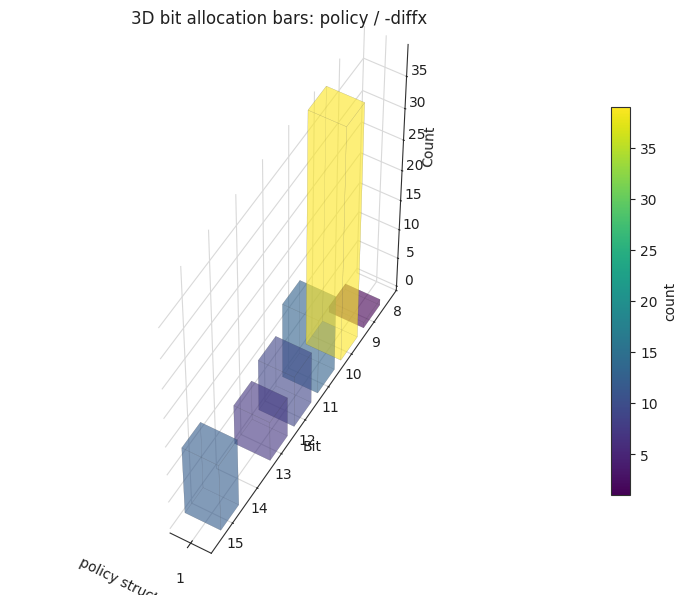

Saved 3D bar plot to: /home/xzha135/work/projects_ws/DAC/STAFI/op_0103/figures/bit_allocation_3dbar_policy_negdiffx_structural.png


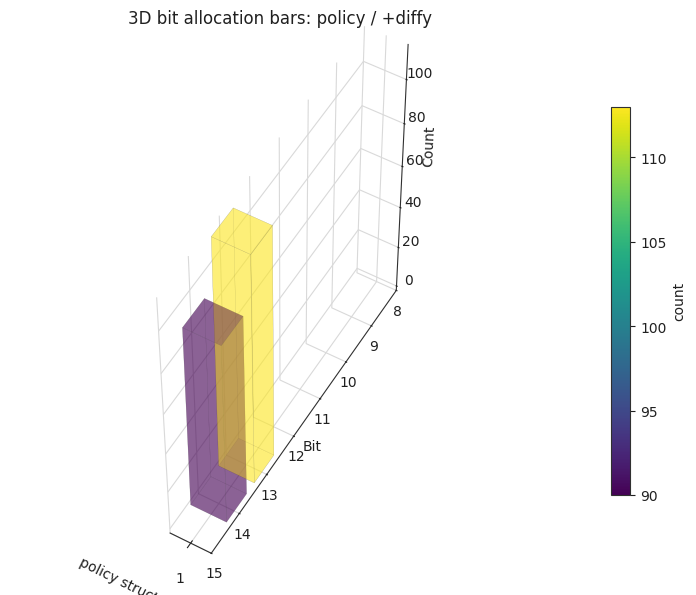

Saved 3D bar plot to: /home/xzha135/work/projects_ws/DAC/STAFI/op_0103/figures/bit_allocation_3dbar_policy_posdiffy_structural.png


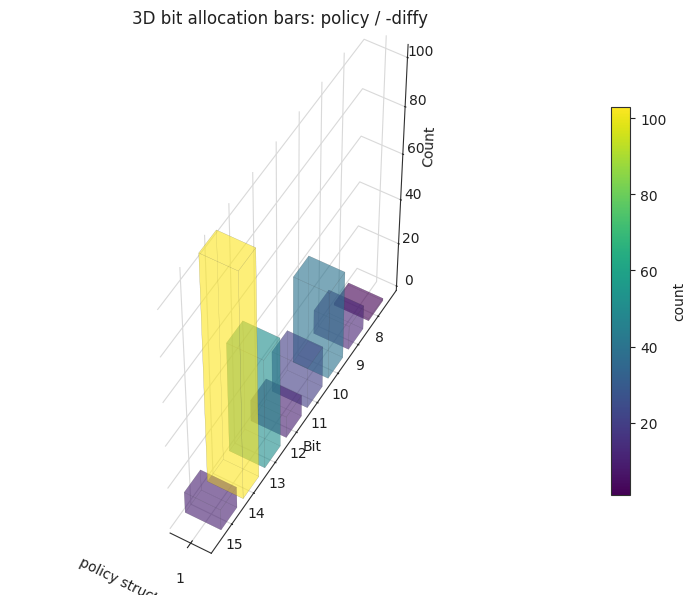

Saved 3D bar plot to: /home/xzha135/work/projects_ws/DAC/STAFI/op_0103/figures/bit_allocation_3dbar_policy_negdiffy_structural.png


In [4]:
def draw_3d_metric_bit_allocation(selected_metric_name, selected_group):
    available_metrics = sorted({
        row["metric"]
        for row in df_bits
        if row["model_group"] == selected_group
    })
    if selected_metric_name not in available_metrics:
        raise ValueError(
            f"Unsupported metric for {selected_group}: {selected_metric_name}. Available: {available_metrics}"
        )

    selected_rows = [
        row
        for row in df_bits
        if row["metric"] == selected_metric_name and row["model_group"] == selected_group
    ]
    layer_ids = list(range(1, len(layer_maps_by_group[selected_group]) + 1))
    bit_values = sorted({
        row["bit"]
        for row in df_bits
        if row["model_group"] == selected_group
    }, reverse=True)

    if not selected_rows or not layer_ids or not bit_values:
        print(f"Skip empty plot: group={selected_group}, metric={selected_metric_name}")
        return

    layer_to_idx = {layer_id: idx for idx, layer_id in enumerate(layer_ids)}
    bit_to_idx = {bit: idx for idx, bit in enumerate(bit_values)}
    heatmap = np.zeros((len(bit_values), len(layer_ids)), dtype=int)

    for row in selected_rows:
        heatmap[bit_to_idx[row["bit"]], layer_to_idx[row["layer_id"]]] += 1

    xpos = []
    ypos = []
    zpos = []
    dx = []
    dy = []
    dz = []
    base_size = 0.72
    for bit in bit_values:
        for layer_id in layer_ids:
            count = heatmap[bit_to_idx[bit], layer_to_idx[layer_id]]
            if count <= 0:
                continue
            x_center = layer_to_idx[layer_id]
            y_center = bit_to_idx[bit]
            xpos.append(x_center - base_size / 2)
            ypos.append(y_center - base_size / 2)
            zpos.append(0.0)
            dx.append(base_size)
            dy.append(base_size)
            dz.append(float(count))

    xpos = np.array(xpos, dtype=float)
    ypos = np.array(ypos, dtype=float)
    zpos = np.array(zpos, dtype=float)
    dx = np.array(dx, dtype=float)
    dy = np.array(dy, dtype=float)
    dz = np.array(dz, dtype=float)

    fig_width = max(10, len(layer_ids) * 0.6)
    fig_height = max(7, len(bit_values) * 0.85)
    fig = plt.figure(figsize=(fig_width, fig_height))
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection="3d")
    ax.set_facecolor("white")

    if len(dz) > 0:
        norm = plt.Normalize(vmin=float(dz.min()), vmax=float(dz.max()))
        colors = plt.cm.viridis(norm(dz))
        colors[:, 3] = 0.38
        ax.bar3d(
            xpos,
            ypos,
            zpos,
            dx,
            dy,
            dz,
            color=colors,
            edgecolor=(0.25, 0.25, 0.25, 0.28),
            linewidth=0.18,
            shade=False,
            zsort="average",
        )
        mappable = plt.cm.ScalarMappable(norm=norm, cmap="viridis")
        mappable.set_array([])
        colorbar = fig.colorbar(mappable, ax=ax, shrink=0.72, pad=0.08)
        colorbar.set_label("count")
        colorbar.ax.set_facecolor("white")

    ax.set_title(f"3D bit allocation bars: {selected_group} / {selected_metric_name}")
    ax.set_xlabel(f"{selected_group} structural layer index")
    ax.set_ylabel("Bit")
    ax.set_zlabel("Count")
    ax.set_xticks(range(len(layer_ids)))
    ax.set_xticklabels(layer_ids)
    ax.set_yticks(range(len(bit_values)))
    ax.set_yticklabels(bit_values)
    ax.set_box_aspect((len(layer_ids), len(bit_values), max(dz) / max(1, max(dz) / 8) if len(dz) else 1))
    ax.view_init(elev=52, azim=-60)

    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_pane_color((1.0, 1.0, 1.0, 1.0))

    metric_tag = selected_metric_name.replace('+', 'pos').replace('-', 'neg')
    plot_path = OUTPUT_DIR / f"bit_allocation_3dbar_{selected_group}_{metric_tag}_structural.png"
    fig.savefig(plot_path, dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved 3D bar plot to: {plot_path}")
    plt.close(fig)


preferred_metrics = ["loss_mse", "+diffx", "-diffx", "+diffy", "-diffy"]
for model_group in ["vision", "policy"]:
    group_metrics = [
        metric_name
        for metric_name in preferred_metrics
        if any(row["metric"] == metric_name and row["model_group"] == model_group for row in df_bits)
    ]
    print(f"\nDrawing plots for {model_group}: {group_metrics}")
    for metric_name in group_metrics:
        draw_3d_metric_bit_allocation(metric_name, model_group)

In [5]:
for model_group in ["vision", "policy"]:
    group_rows = [row for row in df_bits if row["model_group"] == model_group]
    metric_layer_counter = defaultdict(Counter)
    for row in group_rows:
        metric_layer_counter[row["metric"]][(row["layer_id"], row["layer_key"])] += 1

    print(f"\n==== {model_group.upper()} ====")
    print("Top structural layers per metric:")
    for metric in sorted(metric_layer_counter):
        print(f"\n[{metric}]")
        top_rows = [
            {"layer_id": layer_id, "layer_key": layer_key, "count": count}
            for (layer_id, layer_key), count in metric_layer_counter[metric].most_common(10)
        ]
        print_table(top_rows, ["layer_id", "layer_key", "count"])

    print("\nLayer lookup table:")
    layer_lookup_rows = [
        {"layer_id": layer_id, "layer_key": layer_key}
        for layer_key, layer_id in sorted(layer_maps_by_group[model_group].items(), key=lambda item: item[1])
    ]
    print_table(layer_lookup_rows, ["layer_id", "layer_key"], max_rows=40)

    csv_path = OUTPUT_DIR / f"bit_allocation_table_{model_group}_structural.csv"
    with csv_path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "metric",
                "rank",
                "group_rank",
                "model",
                "model_group",
                "name",
                "layer_key",
                "layer_id",
                "bit",
                "flat",
                "weight_score",
                "metric_delta",
                "metric_value",
            ],
        )
        writer.writeheader()
        writer.writerows(group_rows)
    print(f"Saved flattened table to: {csv_path}")


==== VISION ====
Top structural layers per metric:

[+diffx]
layer_id | layer_key                                | count
---------+------------------------------------------+------
6        | vision._en.stages.1.downsample.proj.1    | 210  
2        | vision._en.stem.2                        | 158  
9        | vision._en.stages.2.downsample.proj.1    | 110  
12       | vision._en.stages.3.downsample.proj.1    | 73   
3        | vision._en.stages.0.blocks.0.token_mixer | 43   
1        | vision._en.stem.1                        | 10   
17       | vision._en.final_conv                    | 10   
5        | vision._en.stages.1.downsample.proj.0    | 8    
16       | vision._en.stages.3.blocks.1.layer_scale | 8    
18       | policy.summarizer.resblock.block_a.0     | 5    

[+diffy]
layer_id | layer_key                                | count
---------+------------------------------------------+------
6        | vision._en.stages.1.downsample.proj.1    | 232  
2        | vision._en.stem.2